<br/>

<div align="center">
<span style="font-size: 2.5em;">Signal and Background Integration</span>
<br/>
<span style="font-size: 1.2em; color: gray;">Workflow for combining WIMP signals with ER backgrounds for SBI training</span>
</div>

## Overview

This notebook demonstrates the complete workflow for training neural density estimators with realistic signal+background scenarios:

1. **Signal-only histograms**: 2D binning in (cS1, cS2) space
2. **Background modeling**: Flat ER background from gamma interactions
3. **Combined datasets**: On-the-fly background injection for training
4. **Validation strategies**: Reproducible vs. stochastic background realizations

In [1]:
# =============================
# IMPORTS AND PATH SETTINGS
# =============================

import os
desired_root_name = "xenon-sbi"  
while os.path.basename(os.getcwd()) != desired_root_name:
    os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))
    
import numpy as np
import matplotlib.pyplot as plt
import torch
from utils.processing import clean_nan_events

In [2]:
# =============================
# LOAD SIGNAL DATA
# =============================

n = 300000
halo = "shm"
datatag = "low"

PT_FILE = f"data/datasets/xenon/s1s2/pt/s1s2_n{n}_{halo}.pt" 
data = torch.load(PT_FILE, weights_only=False)
print(f"Dataset keys: {data.keys()}")

# Extract signal components
theta_list = data["theta"]       # WIMP parameters (m_chi, c_p)
energies_list = data["events"]   # Raw event energies
cs1cs2_list = data["cs1cs2"]     # (cS1, cS2) signals

Dataset keys: dict_keys(['theta', 'features', 'events', 'logcp_range', 'logm_range', 'n_train', 'top_k', 'halo_option', 'shmpp_file', 'mc_config', 'cs1cs2', 'xyz'])


In [3]:
# =============================
# DATA CLEANING
# =============================

energies_list, cs1cs2_list = clean_nan_events(energies_list, cs1cs2_list)
print(f"Cleaned data: {len(cs1cs2_list)} spectra")

Cleaned data: 300000 spectra


## 1. Signal-Only Histograms

Converting event lists to 2D histograms in (cS1, cS2) space for neural network input.

In [4]:
# =============================
# HISTOGRAM UTILITIES
# =============================

def make_histogram(cs1cs2_spectrum, bins=30):
    """
    Build 2D histogram in (cS1, cS2) space.
    
    Parameters:
    -----------
    cs1cs2_spectrum : array (N, 2)
        Event list with (cS1, cS2) coordinates
    bins : int
        Number of bins per dimension
    
    Returns:
    --------
    H : array (bins, bins)
        2D histogram counts
    s1_edges, s2_edges : arrays
        Bin edges for cS1 (linear) and cS2 (log)
    """
    cS1 = cs1cs2_spectrum[:, 0]
    cS2 = cs1cs2_spectrum[:, 1]

    # Define bin edges
    s1_edges = np.linspace(0, 100, bins + 1)        # Linear: 0-100 PE
    s2_edges = np.logspace(2.1, 4.1, bins + 1)      # Log: 10^2.1 - 10^4.1 PE

    # Compute histogram
    H, _, _ = np.histogram2d(cS1, cS2, bins=[s1_edges, s2_edges])

    return H, s1_edges, s2_edges


def plot_histogram(H, s1_edges, s2_edges):
    """Plot 2D histogram in (cS1, cS2) space."""
    plt.figure(figsize=(6, 5))
    plt.pcolormesh(s1_edges, s2_edges, H.T, cmap="viridis", shading="auto")
    plt.colorbar(label="Counts per bin")
    plt.xlabel("cS1 [PE]")
    plt.ylabel("cS2 [PE]")
    plt.yscale("log")
    plt.tight_layout()
    plt.show()

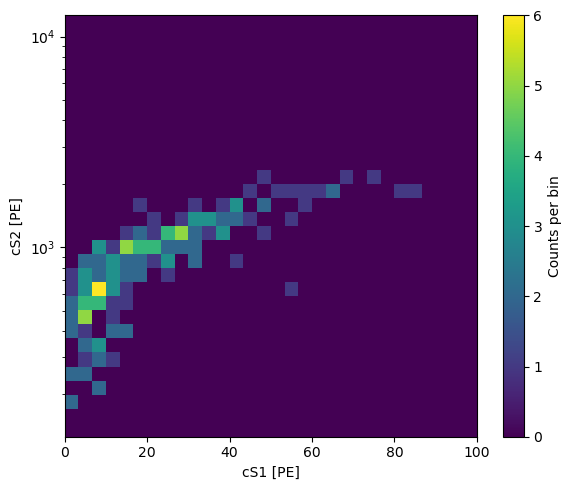

In [5]:
# Example: visualize single spectrum
cs1cs2_spectrum = cs1cs2_list[0]
H, s1_edges, s2_edges = make_histogram(cs1cs2_spectrum, bins=30)
plot_histogram(H, s1_edges, s2_edges)

### Storage Strategy

**Challenge**: Saving pre-computed histograms wastes storage (mostly sparse arrays).

**Solutions**:
1. **On-the-fly histogramming** (preferred): Histogram during training loop
2. **Sparse storage**: Store only (bin_index, count) pairs for non-zero bins

## 2. Electronic Recoil Background

### Background Model

The ER background was simulated using the `fuse` framework with **flat (uniform) gamma-ray events** in the energy range **0-15 keV**.

### Physical Motivation

**1. Compton Continuum Approximation**  
In the low-energy regime (0-15 keV), external gamma backgrounds from radioactive decays (U-238, Th-232, K-40, Co-60, Cs-137) produce predominantly Compton-scattered electrons. The resulting energy spectrum is approximately flat, making a uniform distribution a reasonable first-order approximation.

**2. Signal Region Coverage**  
The 0-15 keV range encompasses the primary WIMP search window where nuclear recoil signals are expected. This ensures the background model is relevant for signal-background discrimination in the region of interest.

**3. Dominant Background Source**  
At these low energies, external gamma-induced ERs constitute the dominant background, significantly exceeding contributions from:
- Kr-83m calibration (32.1 and 9.4 keV lines)
- Tritium β-decay spectrum
- High-energy processes (Xe-133, Xe-136)

**4. Model Simplicity**  
The flat spectrum represents a conservative, model-independent background assumption suitable for initial feasibility studies and provides a worst-case scenario for background discrimination.

### Excluded Backgrounds

Not included in current model (can be added in future):
- Neutron background (nuclear recoils similar to WIMPs)
- Surface events (incomplete charge collection)
- Monochromatic gamma lines (Kr-83m)
- High-energy components (>15 keV)

In [6]:
# =============================
# LOAD BACKGROUND DATA
# =============================

er_data = np.loadtxt(
    "data/datasets/xenon/s1s2/ers/s1s2_ers.csv", 
    delimiter=",", 
    skiprows=1, 
    usecols=(0, 1)
)
print(f"ER background pool: {len(er_data)} events")

ER background pool: 9027194 events


### Background Rate

The number of background events per spectrum is drawn from a **Poisson distribution** to model realistic event count fluctuations.

**Choice**: We use **μ_bg = 150** as the expected number of background events. This is somewhat arbitrary for our purposes but comparable to realistic XENON exposures (see arXiv:2502.18005v2 for SR1b with 1.31 tonne-year exposure).

In [9]:
def plot_s1s2_bg(er_data, n_bg=150, signal=None, saveoption=False):
    """
    Scatterplot of ER background with optional WIMP signal(s).

    Parameters:
    -----------
    er_data : array (N, 2)
        Background events (cS1, cS2)
    n_bg : int
        Expected number of background events (Poisson mean)
    signal : None, array (N, 2), or list of arrays
        Signal events. If None, only background is plotted.
        Can be a single 2D array or list of 2D arrays (concatenated automatically).
    saveoption : bool or str
        If False: do not save
        If True: save to default path
        If str: save to specified path
    """
    color_signal = "#FF7F50"
    color_bg    = "#4067B1"

    # Sample background events from Poisson
    n_bg_actual = np.random.poisson(n_bg)
    indices = np.random.choice(len(er_data), size=n_bg_actual, replace=False)
    bg_sample = er_data[indices]
    cs1_bg = bg_sample[:, 0]
    cs2_bg = bg_sample[:, 1]

    # Extract and concatenate signal if provided
    if signal is not None:
        if isinstance(signal, list):
            signal = np.concatenate(signal)
        cs1_signal = signal[:, 0]
        cs2_signal = signal[:, 1]
    else:
        cs1_signal, cs2_signal = None, None

    # Plot
    fig, ax = plt.subplots(figsize=(7, 6))

    ax.scatter(cs1_bg, cs2_bg, s=60, color=color_bg, label="ER", alpha=0.7)
    if signal is not None:
        ax.scatter(cs1_signal, cs2_signal, s=60, color=color_signal, label="NR", alpha=0.7)
    
    ax.set_xlim(0, 100)
    ax.set_xticks(np.arange(0, 101, 20))
    ax.set_ylim(10**2.1, 10**4.1)
    ax.set_yscale("log")
    ax.set_xlabel("cS1 [PE]", fontsize=24)
    ax.set_ylabel("cS2 [PE]", fontsize=24)
    ax.tick_params(axis="both", labelsize=22)
    ax.grid(True, ls="--", alpha=0.3)
    ax.legend(fontsize=22, loc="lower right", markerscale=3)
    plt.tight_layout()

    if saveoption:
        if isinstance(saveoption, str):
            filepath = saveoption
        else:
            filepath = "figures/s1s2_bg_plot.pdf"
        fig.savefig(filepath, format="pdf", dpi=300, bbox_inches="tight")
        print(f"Figure saved to {filepath}")

    plt.show()

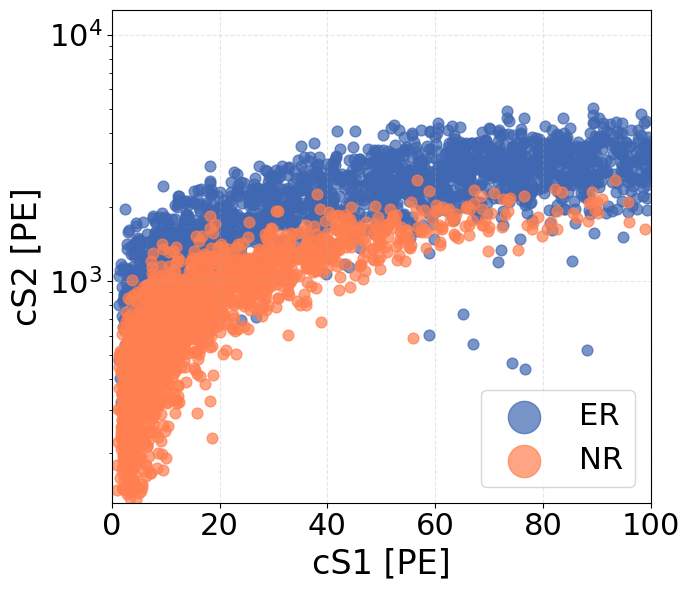

In [26]:
# ===============
# VISUALIZATION
# ===============

plot_s1s2_bg(er_data, n_bg=2000, signal=cs1cs2_list[:200], saveoption=None)

<br><br><br>
# Plotting on Parameter Grid
<br>


Before building histograms for training, we visualize the raw (cS1, cS2)
distributions on a parameter grid to develop intuition for the signal and
background morphology. WIMP signal events (red) are overlaid with a
Poisson-sampled ER background (blue, $\mu_\mathrm{bg} = 150$). The ER band
sits clearly above the NR signal band in cS2, reflecting the different
charge-to-light ratios discussed in Chapter 4. At low masses and small
couplings the signal becomes sparse and increasingly difficult to distinguish
from the background, motivating the need for a powerful inference method.

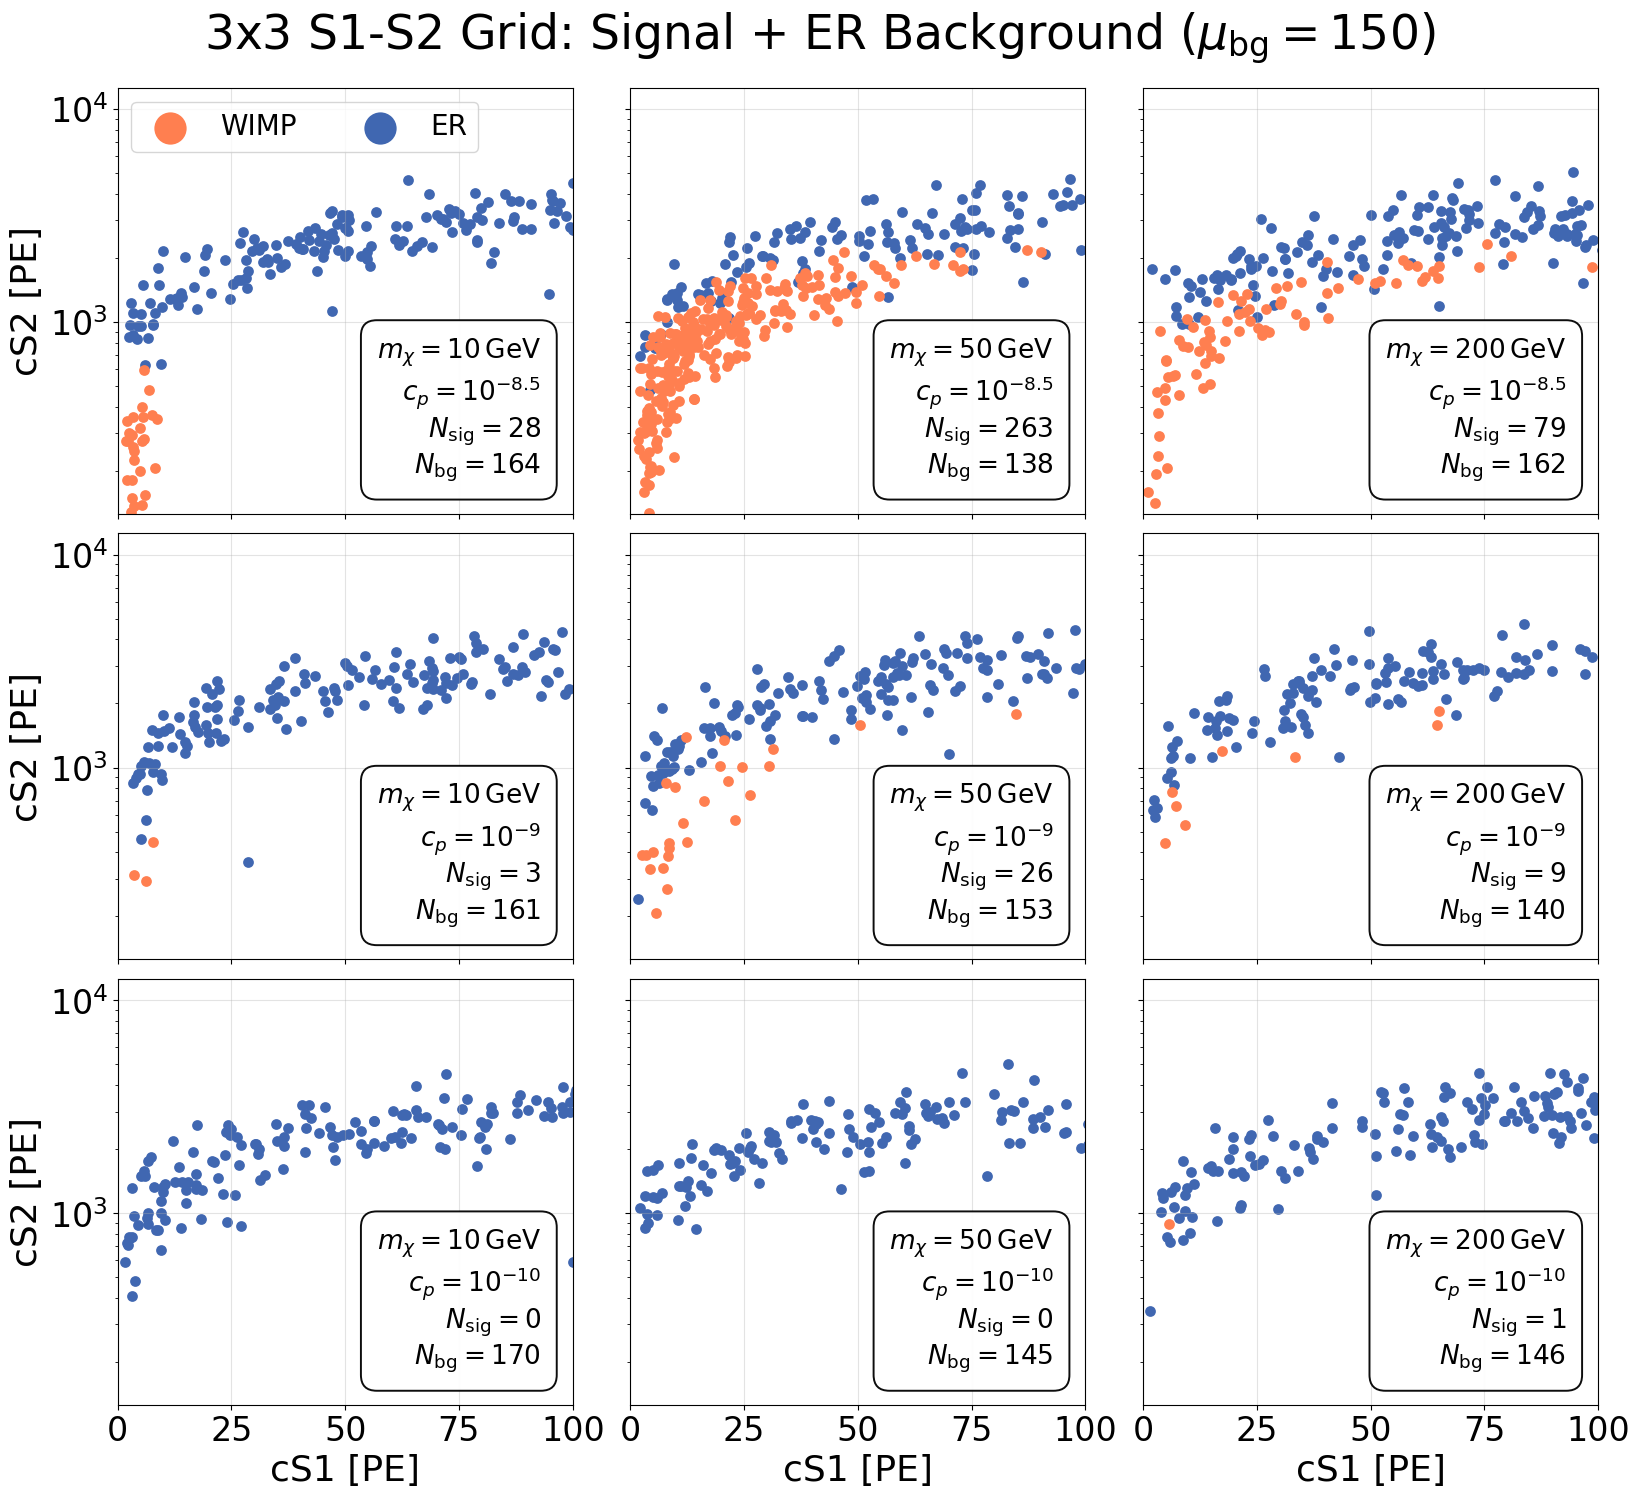

In [11]:
# =============================
# 3x3 GRID: S1-S2 SCATTER PLOTS WITH ER BACKGROUND
# =============================

grid_dim = 3
logms   = np.log10(np.array([10, 50, 200], dtype=float))
logcps  = np.array([-8.5, -9.0, -10.0], dtype=float)

if len(logms) != grid_dim or len(logcps) != grid_dim:
    raise ValueError("grid_dim must match the number of mass and coupling entries")

masses_grid    = np.rint(10**logms).astype(int).tolist()
couplings_grid = (10**logcps).tolist()

theta_arr = np.asarray(theta_list)  # shape (N, 2)

def cp_power_label(logcp):
    if np.isclose(logcp, round(logcp)):
        exp_str = f"{int(round(logcp))}"
    else:
        exp_str = f"{logcp:.1f}"
    return rf"$c_p = 10^{{{exp_str}}}$"

def format_nevents(nevents):
    if np.isclose(nevents, round(nevents)):
        return str(int(round(nevents)))
    return f"{nevents:.2f}"

MU_bg = 150

# --- Find nearest spectrum for each grid point ---
all_spectra_s1s2 = {}
for r in range(grid_dim):
    for c in range(grid_dim):
        logm_t = logms[c]
        logc_t = logcps[r]
        dist   = (theta_arr[:, 0] - logm_t)**2 + (theta_arr[:, 1] - logc_t)**2
        idx    = int(np.argmin(dist))
        spectrum = cs1cs2_list[idx]
        arr      = np.asarray(spectrum)
        arr      = arr[np.isfinite(arr).all(axis=1)]
        nevents  = len(arr)
        all_spectra_s1s2[(r, c)] = (arr, nevents, theta_arr[idx])

# --- Plot ---
fig, axes = plt.subplots(
    grid_dim, grid_dim,
    figsize=(5.5 * grid_dim, 5.0 * grid_dim),
    sharex=True, sharey=True,
)
axes = np.array(axes).reshape(grid_dim, grid_dim)

color_signal = "#FF7F50"
color_bg    = "#4067B1"

for r in range(grid_dim):
    for c in range(grid_dim):
        ax = axes[r, c]
        arr, nevents, theta_real = all_spectra_s1s2[(r, c)]
        mchi = int(round(10**logms[c]))

        # --- Sample background ---
        n_bg_actual = np.random.poisson(MU_bg)
        indices      = np.random.choice(len(er_data), size=n_bg_actual, replace=False)
        bg_sample   = er_data[indices]

        # --- Plot signal ---
        if len(arr) > 0:
            ax.scatter(
                arr[:, 0], arr[:, 1],
                s=60,
                color=color_signal,
                alpha=1,
                linewidths=0,
                label="WIMP",
                zorder=2,
            )

        # --- Plot background ---
        ax.scatter(
            bg_sample[:, 0], bg_sample[:, 1],
            s=60,
            color=color_bg,
            alpha=1,
            linewidths=0,
            label="ER",
            zorder=1,
        )

        # Axes
        ax.set_xlim(0, 100)
        ax.set_yscale("log")
        ax.set_ylim(10**2.1, 10**4.1)
        ax.grid(alpha=0.35, linewidth=0.8)
        ax.tick_params(axis="both", labelsize=24)

        if r == grid_dim - 1:
            ax.set_xlabel("cS1 [PE]", fontsize=26)
        if c == 0:
            ax.set_ylabel("cS2 [PE]", fontsize=26)

        # Legend only in first panel
        if r == 0 and c == 0:
            ax.legend(fontsize=20, loc="upper left", ncol=2, markerscale=3)

        # Boxed annotation in lower right
        n_label   = format_nevents(nevents)
        info_text = (
            rf"$m_\chi = {mchi}\,\mathrm{{GeV}}$" + "\n" +
            cp_power_label(logcps[r]) + "\n" +
            rf"$N_\mathrm{{sig}} = {n_label}$" + "\n" +
            rf"$N_\mathrm{{bg}} = {n_bg_actual}$"
        )
        ax.text(
            0.93, 0.07, info_text,
            transform=ax.transAxes,
            va="bottom", ha="right",
            fontsize=19,
            bbox=dict(
                boxstyle="round,pad=0.6",
                facecolor="white",
                edgecolor="black",
                linewidth=1.4,
                alpha=0.95,
            )
        )

fig.suptitle(
    f"{grid_dim}x{grid_dim} S1-S2 Grid: Signal + ER Background "
    rf"($\mu_\mathrm{{bg}} = {MU_bg}$)",
    fontsize=34, y=0.995
)
plt.tight_layout()

#pdf_path = "figures/..."
#fig.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")
#print(f"Figure saved to {pdf_path}")
plt.show()

## 3. SBI Training with Signal + Background

### Training Strategy: On-the-Fly Background Injection

#### 1. Data Storage (Minimal Footprint)
- **Signal events**: Variable-length tensors for each spectrum
- **Signal parameters**: $\theta = (m_\chi , c_p)$
- **Background pool**: Large independent event collection
- **No pre-computed histograms** (sparse and inflexible)

#### 2. Dataset with Stochastic Background
Each `__getitem__` call:
1. Samples Poisson number of background events: `N_bg ~ Poisson(μ_bg)`
2. Draws `N_bg` events from background pool
3. Concatenates with signal events
4. Histograms combined events into fixed-size array

**Benefit**: Per-epoch randomization ensures correct marginalization over background realizations.

#### 3. Training Workflow

**Load offline data**:
```python
signal_events.pt   # List of [N_i, 2] tensors
theta.pt           # [N_samples, dim_theta]
background.pt      # [N_bg_total, 2] tensor
```

**Build dataset**:
```python
train_dataset = SignalPlusBackgroundDataset(
    signal_events=signal_events,
    theta=theta,
    background_events=background_events,
    mu_bg=150.0,
    s1_bins=30, s2_bins=30,
    s1_range=(0, 100),
    s2_range=(10**2.1, 10**4.1)
)
```

Each batch sees **same signal, different background realizations**.

#### 4. Validation Strategy
- Fix background realizations (`reproducible=True`) for stable metrics
- Prevents noisy evaluation due to stochastic background

#### 5. Advantages
- ✓ Small storage footprint
- ✓ Flexible binning or summary statistics
- ✓ Naturally handles fluctuating event counts
- ✓ Easily extended to:
  - Background as nuisance parameter
  - Multiple background components
  - DeepSets / set-based architectures

In [12]:
# =============================
# IMPORT DATASET CLASS
# =============================

from utils.processing import SignalPlusBackgroundDataset

### Example 1: Signal Only (No Background)

In [13]:
# Create dataset with zero background
signal_only_dataset = SignalPlusBackgroundDataset(
    signal_events=cs1cs2_list,
    theta=theta_list,
    background_events=er_data,
    mu_bg=0,  # No background
    s1_bins=30,
    s2_bins=30,
    s1_range=(0, 100),
    s2_range=(10**2.1, 10**4.1)
)

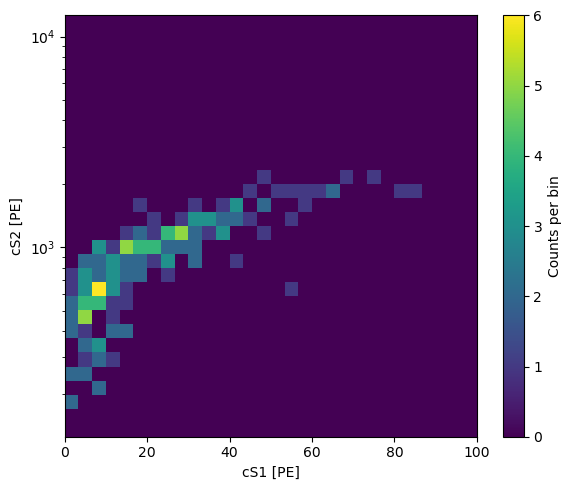

In [16]:
# Visualize examples
for i in range(1):
    plot_histogram(
        signal_only_dataset[i][0],
        signal_only_dataset.s1_edges,
        signal_only_dataset.s2_edges
    )

### Example 2: Signal + Background (Training Mode)

In [18]:
# Create dataset with stochastic background
signal_bg_dataset = SignalPlusBackgroundDataset(
    signal_events=cs1cs2_list,
    theta=theta_list,
    background_events=er_data,
    mu_bg=150,  
    s1_bins=30,
    s2_bins=30,
    s1_range=(0, 100),
    s2_range=(10**2.1, 10**4.1)
)

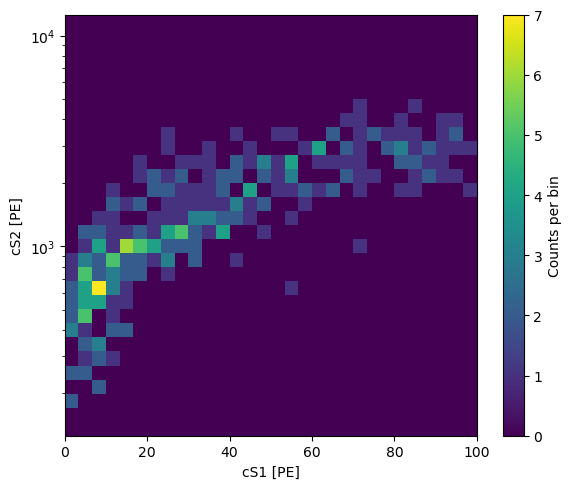

In [19]:
# Visualize examples (different background each time)
for i in range(1):
    plot_histogram(
        signal_bg_dataset[i][0],
        signal_bg_dataset.s1_edges,
        signal_bg_dataset.s2_edges
    )

### Example 3: Signal + Background (Validation Mode)

In [20]:
# Create dataset with fixed background (reproducible)
signal_bg_validation_dataset = SignalPlusBackgroundDataset(
    signal_events=cs1cs2_list,
    theta=theta_list,
    background_events=er_data,
    mu_bg=150,
    s1_bins=30,
    s2_bins=30,
    s1_range=(0, 100),
    s2_range=(10**2.1, 10**4.1),
    reproducible=True,  # Fix random seed
    rng_seed=42
)

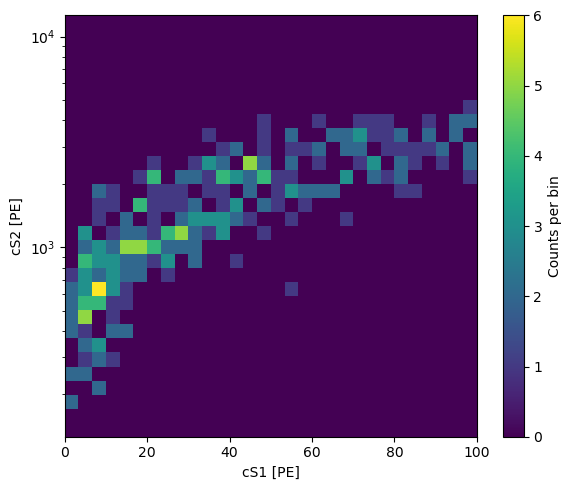

In [21]:
# Visualize examples (same background each time)
for i in range(1):
    plot_histogram(
        signal_bg_validation_dataset[i][0],
        signal_bg_validation_dataset.s1_edges,
        signal_bg_validation_dataset.s2_edges
    )

## Summary

**Training vs. Validation**:
- **Training dataset**: `reproducible=False` → Different background realization each epoch
- **Validation dataset**: `reproducible=True` → Fixed background for consistent metrics

This approach ensures proper uncertainty quantification while maintaining stable performance evaluation.

## 4. Histogram Grids (Signal-only and Signal+Background)

The next two figures mirror the 3x3 scatter grids, but use 2D histograms per panel.

Set `BINS_HIST` to control the histogram resolution.

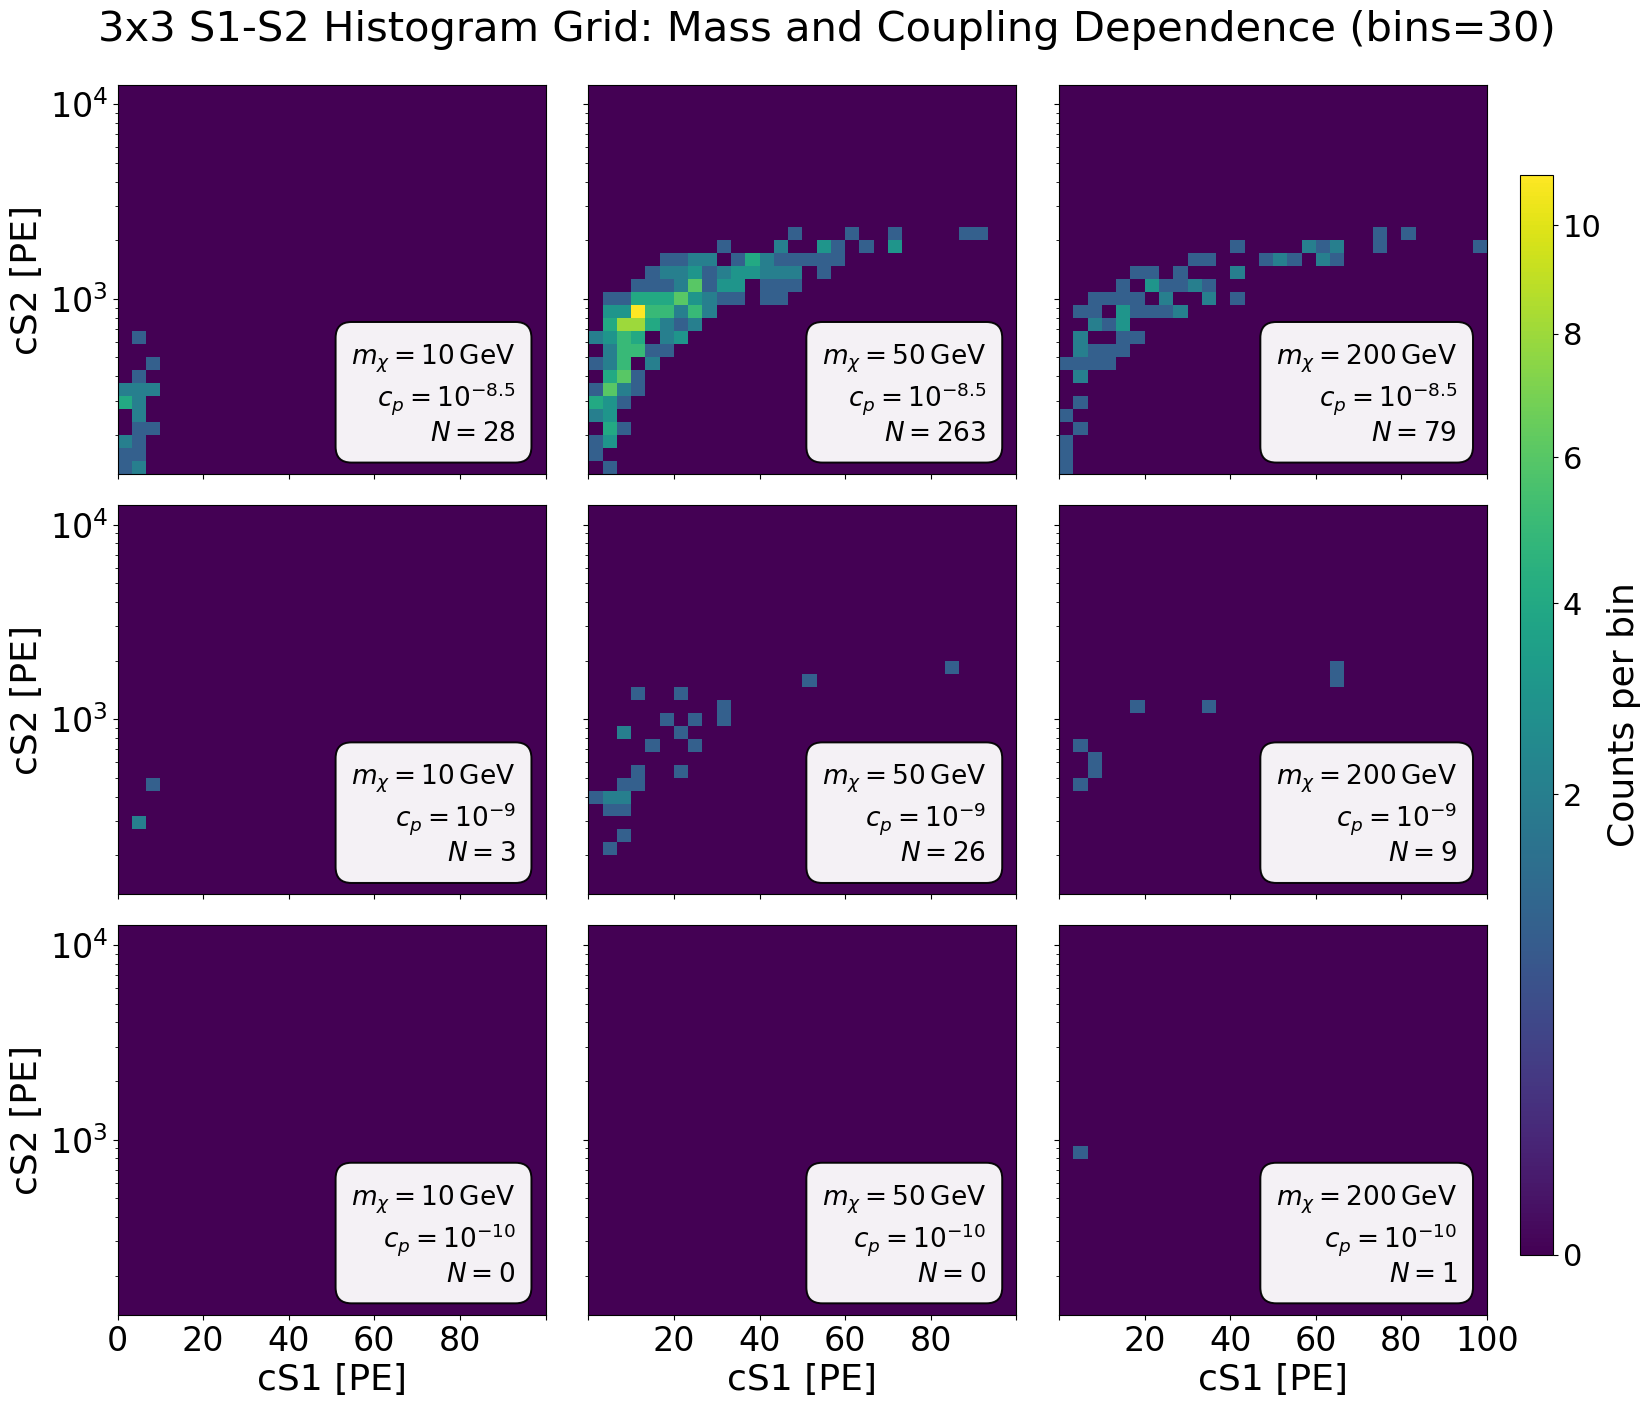

In [23]:
# =============================
# 3x3 GRID: S1-S2 HISTOGRAMS (SIGNAL ONLY)
# =============================

from matplotlib import colors as mcolors

BINS_HIST = 30  # variable input
GAMMA = 0.5   # variable input for color normalization (lower = more contrast in low-count bins)

grid_dim = 3
logms = np.log10(np.array([10, 50, 200], dtype=float))
logcps = np.array([-8.5, -9.0, -10.0], dtype=float)

if len(logms) != grid_dim or len(logcps) != grid_dim:
    raise ValueError("grid_dim must match the number of mass and coupling entries")

theta_arr = np.asarray(theta_list)


def cp_power_label(logcp):
    if np.isclose(logcp, round(logcp)):
        exp_str = f"{int(round(logcp))}"
    else:
        exp_str = f"{logcp:.1f}"
    return rf"$c_p = 10^{{{exp_str}}}$"


def format_nevents(nevents):
    if np.isclose(nevents, round(nevents)):
        return str(int(round(nevents)))
    return f"{nevents:.2f}"


# --- Find nearest spectrum for each grid point ---
all_spectra_s1s2 = {}
for r in range(grid_dim):
    for c in range(grid_dim):
        logm_t = logms[c]
        logc_t = logcps[r]
        dist = (theta_arr[:, 0] - logm_t) ** 2 + (theta_arr[:, 1] - logc_t) ** 2
        idx = int(np.argmin(dist))
        spectrum = cs1cs2_list[idx]
        arr = np.asarray(spectrum)
        arr = arr[np.isfinite(arr).all(axis=1)]
        nevents = len(arr)
        all_spectra_s1s2[(r, c)] = (arr, nevents, theta_arr[idx])

s1_edges = np.linspace(0, 100, BINS_HIST + 1)
s2_edges = np.logspace(2.1, 4.1, BINS_HIST + 1)

# Build all panel histograms first to enforce one shared color scale.
histograms = {}
global_vmax = 0.0
for r in range(grid_dim):
    for c in range(grid_dim):
        arr, nevents, theta_real = all_spectra_s1s2[(r, c)]
        H = np.zeros((BINS_HIST, BINS_HIST), dtype=float)
        if len(arr) > 0:
            H, _, _ = np.histogram2d(arr[:, 0], arr[:, 1], bins=[s1_edges, s2_edges])
        histograms[(r, c)] = H
        global_vmax = max(global_vmax, float(H.max()))

vmax = max(global_vmax, 1.0)
norm = mcolors.PowerNorm(gamma=GAMMA, vmin=0.0, vmax=vmax)

# --- Plot ---
fig, axes = plt.subplots(
    grid_dim,
    grid_dim,
    figsize=(5.5 * grid_dim, 5.0 * grid_dim),
    sharex=True,
    sharey=True,
)
axes = np.array(axes).reshape(grid_dim, grid_dim)

pcm = None
for r in range(grid_dim):
    for c in range(grid_dim):
        ax = axes[r, c]
        arr, nevents, theta_real = all_spectra_s1s2[(r, c)]
        mchi = int(round(10 ** logms[c]))
        H = histograms[(r, c)]

        pcm = ax.pcolormesh(
            s1_edges,
            s2_edges,
            H.T,
            cmap="viridis",
            norm=norm,
            shading="auto",
            rasterized=True,
        )

        ax.set_xlim(0, 100)
        ax.set_yscale("log")
        ax.set_ylim(10**2.1, 10**4.1)
        #ax.grid(alpha=0.35, linewidth=0.8)
        ax.tick_params(axis="both", labelsize=24)

        if r == grid_dim - 1:
            ax.set_xlabel("cS1 [PE]", fontsize=26)
            xticks = np.arange(0, 101, 20)
            ax.set_xticks(xticks)
            # Avoid overlapping boundary labels between neighboring subplots.
            if c > 0:
                ax.xaxis.get_major_ticks()[0].label1.set_visible(False)
            if c < grid_dim - 1:
                ax.xaxis.get_major_ticks()[-1].label1.set_visible(False)
        if c == 0:
            ax.set_ylabel("cS2 [PE]", fontsize=26)

        n_label = format_nevents(nevents)
        info_text = (
            rf"$m_\chi = {mchi}\,\mathrm{{GeV}}$"
            + "\n"
            + cp_power_label(logcps[r])
            + "\n"
            + rf"$N = {n_label}$"
        )
        ax.text(
            0.93,
            0.07,
            info_text,
            transform=ax.transAxes,
            va="bottom",
            ha="right",
            fontsize=19,
            bbox=dict(
                boxstyle="round,pad=0.6",
                facecolor="white",
                edgecolor="black",
                linewidth=1.4,
                alpha=0.95,
            ),
        )

fig.suptitle(
    f"{grid_dim}x{grid_dim} S1-S2 Histogram Grid: Mass and Coupling Dependence (bins={BINS_HIST})",
    fontsize=30,
    y=0.95,
)

# Manual layout avoids tight_layout/colorbar conflicts.
fig.subplots_adjust(left=0.07, right=0.90, bottom=0.08, top=0.90, wspace=0.10, hspace=0.08)
cax = fig.add_axes([0.92, 0.12, 0.02, 0.72])
cbar = fig.colorbar(pcm, cax=cax)
cbar.set_label("Counts per bin", fontsize=26)
cbar.ax.tick_params(labelsize=22)

#pdf_path = "figures/..."
#fig.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")
#print(f"Figure saved to {pdf_path}")
plt.show()

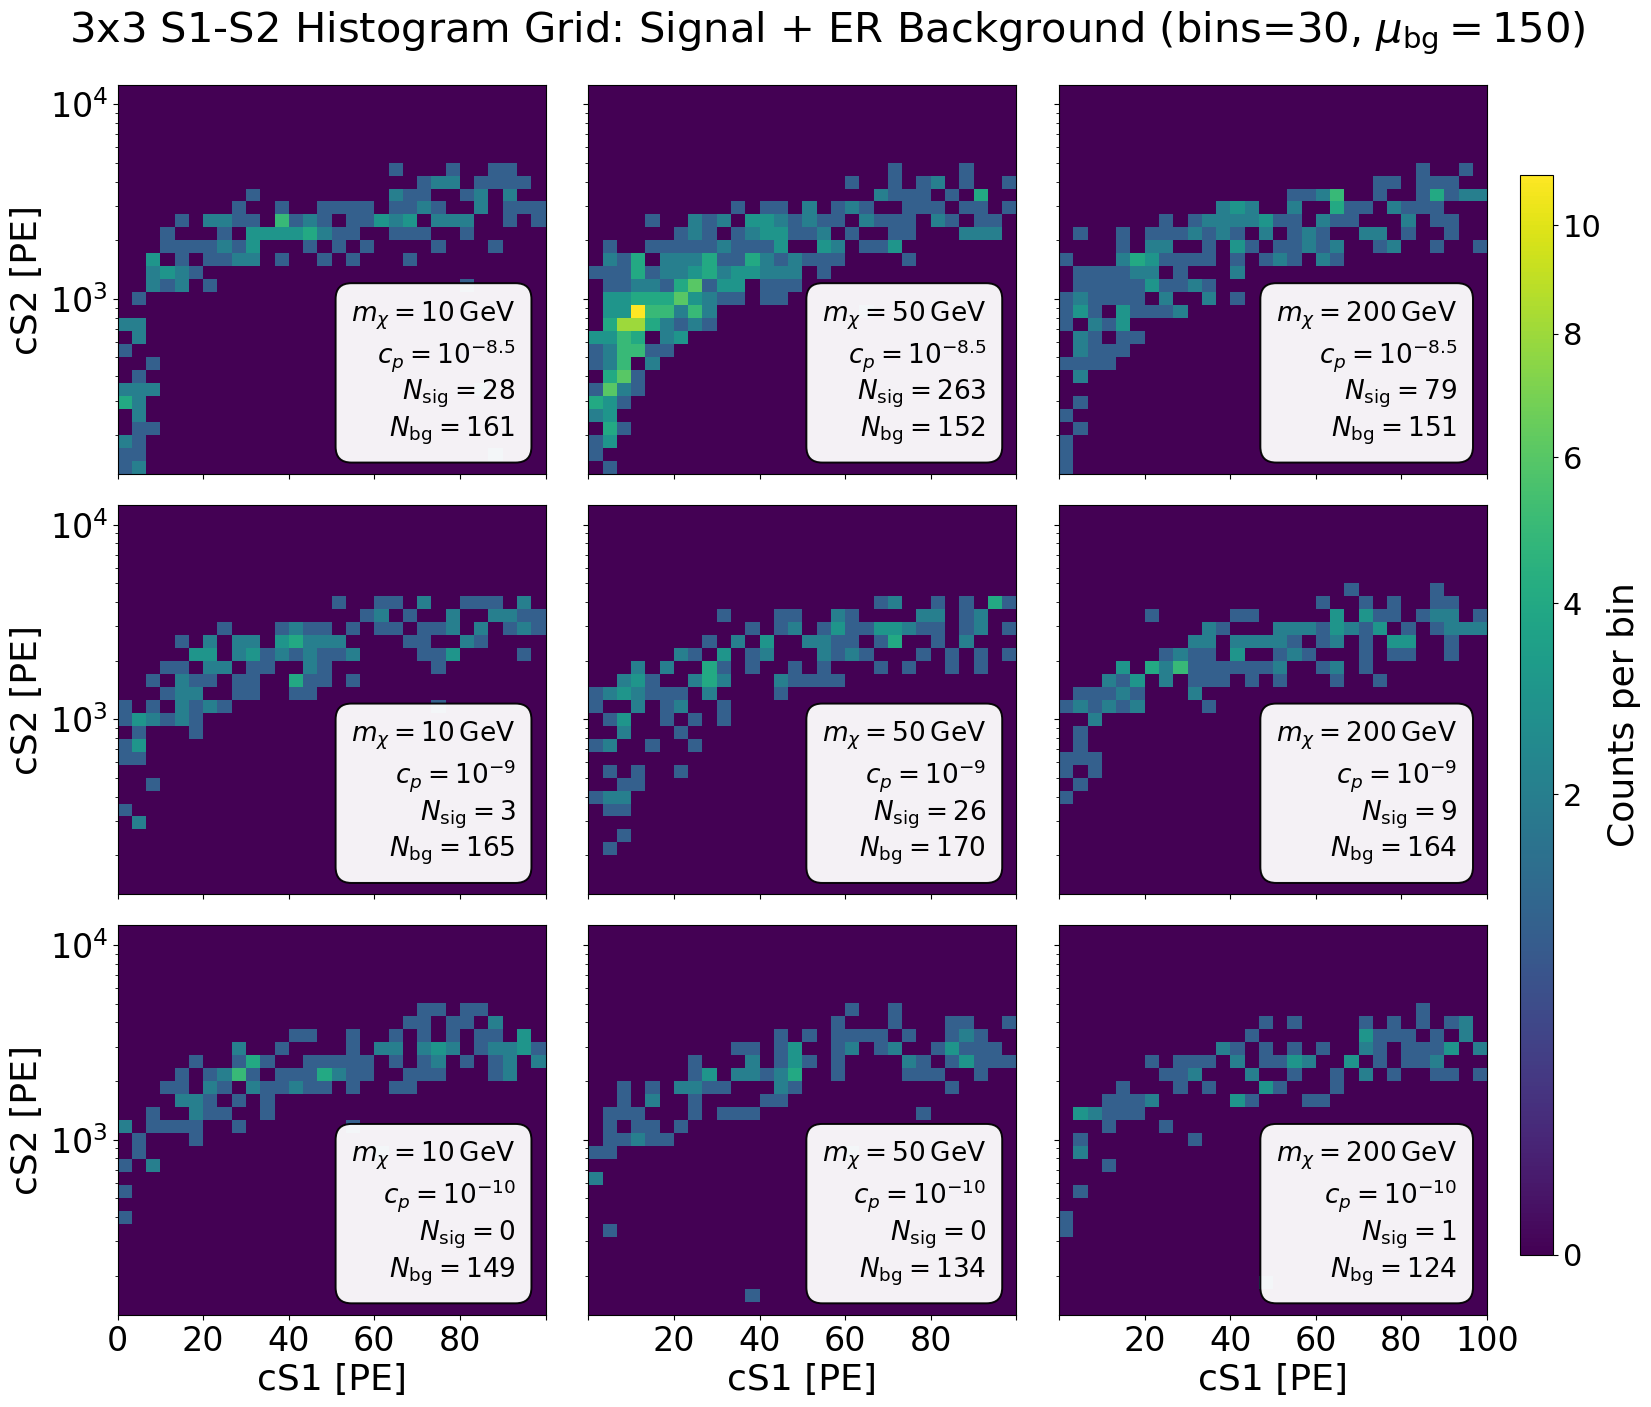

In [24]:
# =============================
# 3x3 GRID: S1-S2 HISTOGRAMS WITH ER BACKGROUND
# =============================

from matplotlib import colors as mcolors

# Use the same value as scatter figure unless you want to change it.
MU_bg = 150
# Reuse variable bin input from previous cell.
GAMMA = 0.5   # variable input for color normalization (lower = more contrast in low-count bins)

s1_edges = np.linspace(0, 100, BINS_HIST + 1)
s2_edges = np.logspace(2.1, 4.1, BINS_HIST + 1)

# Build all panel histograms first to enforce one shared color scale.
panel_data = {}
global_vmax = 0.0
for r in range(grid_dim):
    for c in range(grid_dim):
        arr, nevents, theta_real = all_spectra_s1s2[(r, c)]
        n_bg_actual = np.random.poisson(MU_bg)
        idx_bg = np.random.choice(len(er_data), size=n_bg_actual, replace=False)
        bg_sample = er_data[idx_bg]

        if len(arr) > 0:
            combined = np.vstack([arr, bg_sample])
        else:
            combined = bg_sample

        combined = combined[np.isfinite(combined).all(axis=1)]

        H = np.zeros((BINS_HIST, BINS_HIST), dtype=float)
        if len(combined) > 0:
            H, _, _ = np.histogram2d(combined[:, 0], combined[:, 1], bins=[s1_edges, s2_edges])

        panel_data[(r, c)] = {
            "H": H,
            "nevents": nevents,
            "n_bg_actual": n_bg_actual,
        }
        global_vmax = max(global_vmax, float(H.max()))

vmax = max(global_vmax, 1.0)
norm = mcolors.PowerNorm(gamma=GAMMA, vmin=0.0, vmax=vmax)

fig, axes = plt.subplots(
    grid_dim,
    grid_dim,
    figsize=(5.5 * grid_dim, 5.0 * grid_dim),
    sharex=True,
    sharey=True,
)
axes = np.array(axes).reshape(grid_dim, grid_dim)

pcm = None
for r in range(grid_dim):
    for c in range(grid_dim):
        ax = axes[r, c]
        mchi = int(round(10 ** logms[c]))

        H = panel_data[(r, c)]["H"]
        nevents = panel_data[(r, c)]["nevents"]
        n_bg_actual = panel_data[(r, c)]["n_bg_actual"]

        pcm = ax.pcolormesh(
            s1_edges,
            s2_edges,
            H.T,
            cmap="viridis",
            norm=norm,
            shading="auto",
            rasterized=True,
        )

        ax.set_xlim(0, 100)
        ax.set_yscale("log")
        ax.set_ylim(10**2.1, 10**4.1)
        #ax.grid(alpha=0.35, linewidth=0.8)
        ax.tick_params(axis="both", labelsize=24)

        if r == grid_dim - 1:
            ax.set_xlabel("cS1 [PE]", fontsize=26)
            xticks = np.arange(0, 101, 20)
            ax.set_xticks(xticks)
            # Avoid overlapping boundary labels between neighboring subplots.
            if c > 0:
                ax.xaxis.get_major_ticks()[0].label1.set_visible(False)
            if c < grid_dim - 1:
                ax.xaxis.get_major_ticks()[-1].label1.set_visible(False)
        if c == 0:
            ax.set_ylabel("cS2 [PE]", fontsize=26)

        n_label = format_nevents(nevents)
        info_text = (
            rf"$m_\chi = {mchi}\,\mathrm{{GeV}}$"
            + "\n"
            + cp_power_label(logcps[r])
            + "\n"
            + rf"$N_\mathrm{{sig}} = {n_label}$"
            + "\n"
            + rf"$N_\mathrm{{bg}} = {n_bg_actual}$"
        )
        ax.text(
            0.93,
            0.07,
            info_text,
            transform=ax.transAxes,
            va="bottom",
            ha="right",
            fontsize=19,
            bbox=dict(
                boxstyle="round,pad=0.6",
                facecolor="white",
                edgecolor="black",
                linewidth=1.4,
                alpha=0.95,
            ),
        )

fig.suptitle(
    f"{grid_dim}x{grid_dim} S1-S2 Histogram Grid: Signal + ER Background (bins={BINS_HIST}, $\\mu_\\mathrm{{bg}}={MU_bg}$)",
    fontsize=30,
    y=0.95,
)

# Manual layout avoids tight_layout/colorbar conflicts.
fig.subplots_adjust(left=0.07, right=0.90, bottom=0.08, top=0.90, wspace=0.10, hspace=0.08)
cax = fig.add_axes([0.92, 0.12, 0.02, 0.72])
cbar = fig.colorbar(pcm, cax=cax)
cbar.set_label("Counts per bin", fontsize=26)
cbar.ax.tick_params(labelsize=22)

#pdf_path = "figures/..."
#fig.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")
#print(f"Figure saved to {pdf_path}")
plt.show()